# Final Interpretability Analysis

This notebook is a dedicated interpretability analysis for the final movie recommendation system. The final application uses the **Hybrid Ranker**, so most of the analysis focuses on understanding how that model recommends movies.

The goal is to maximize transparency from several angles:

- local explanation: why one user received one recommendation
- component explanation: how item similarity, popularity, and genre affinity contributed
- evidence explanation: which liked movies support the recommendation
- SHAP-style explanation: additive attribution over structured hybrid features
- global explanation: which signals dominate across many users
- counterfactual explanation: how recommendations change when weights or diversity change
- optional neural explanation: genre occlusion sensitivity for Ranking NeuMF

The final notebook avoids explaining opaque neural embedding dimensions directly because those dimensions do not have stable human-readable meaning.

In [1]:
from pathlib import Path
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\rafal\OneDrive\Dokumente\GitHub\Movie-Recommendation-System-with-Explainability


## 1. Load Final Recommender

The final deployed model is the `HybridRanker`. It combines:

- item-item KNN similarity
- Bayesian-smoothed popularity
- genre affinity

Default weights:

```text
item_knn = 0.50
popularity = 0.25
genre = 0.25
```


In [2]:
from src.hybrid_ranker import HybridRanker, DEFAULT_HYBRID_WEIGHTS
from src.explainability import (
    bayesian_popularity_breakdown,
    genre_affinity_breakdown,
    hybrid_component_contributions,
    shap_hybrid_values,
)

ranker = HybridRanker(diversity_weight=0.05)
available_users = ranker.available_user_ids()

model_overview = pd.DataFrame(
    [
        {"component": "item-item KNN", "weight": DEFAULT_HYBRID_WEIGHTS["item_knn"], "meaning": "similarity to movies the user liked"},
        {"component": "popularity", "weight": DEFAULT_HYBRID_WEIGHTS["popularity"], "meaning": "Bayesian-smoothed global reception"},
        {"component": "genre affinity", "weight": DEFAULT_HYBRID_WEIGHTS["genre"], "meaning": "match with user's genre profile"},
    ]
)

print(f"Available users: {len(available_users)}")
display(model_overview)

Available users: 610


,component,weight,meaning
0,item-item KNN,0.50,similarity to movies the user liked
1,popularity,0.25,Bayesian-smoothed global reception
2,genre affinity,0.25,match with user's genre profile


## 2. Local Explanation For One User

A local explanation answers: **Why did this specific user receive these specific movies?**

We inspect:

- the user's liked history
- the top recommendations
- component scores
- explanation summary
- similar liked movies used as evidence


In [3]:
# Choose a user with a meaningful rating history.
user_activity = ranker.item_engine.train_df.groupby("userId").size().sort_values(ascending=False)
demo_user = int(user_activity.index[0])

liked_movies = ranker.user_liked_movies(demo_user, limit=10)
recommendations = ranker.recommend_for_user(demo_user, top_n=10, diversity_weight=0.05)

print(f"Demo user: {demo_user}")
print("Movies from this user's positive history:")
display(liked_movies)

recommendation_cols = [
    "movieId", "title", "genres", "relevance_score",
    "item_knn_score", "popularity_score", "genre_score",
    "explanation_summary",
]
display(recommendations[recommendation_cols])

Demo user: 414
Movies from this user's positive history:


,movieId,title,rating
0,8784,Garden State (2004),5.0
1,6370,"Spanish Apartment, The (L'auberge espagnole) (...",5.0
2,6159,All the Real Girls (2003),5.0
3,6442,Belle époque (1992),5.0
4,11,"American President, The (1995)",5.0
5,5991,Chicago (2002),5.0
6,5328,Rain (2001),5.0
7,6218,Bend It Like Beckham (2002),5.0
8,5902,Adaptation (2002),5.0
9,5577,Igby Goes Down (2002),5.0


,movieId,title,genres,relevance_score,item_knn_score,popularity_score,genre_score,explanation_summary
0,39414,Shopgirl (2005),Comedy | Drama | Romance,0.8798,1.0000,0.5688,0.9505,Main signal: similarity to movies the user liked.
1,3430,Death Wish (1974),Action | Crime | Drama,0.8413,1.0000,0.6111,0.7539,Main signal: similarity to movies the user liked.
2,7000,Hudson Hawk (1991),Action | Adventure | Comedy,0.8127,1.0000,0.6111,0.6396,Main signal: similarity to movies the user liked.
3,2978,Three to Tango (1999),Comedy | Romance,0.8034,1.0000,0.5972,0.6163,Main signal: similarity to movies the user liked.
4,1185,My Left Foot (1989),Drama,0.7632,0.7715,0.7348,0.7748,Main signal: similarity to movies the user liked.
5,79132,Inception (2010),Action | Crime | Drama | IMAX | Mystery | Sci-...,0.7609,0.7166,0.9200,0.6903,Main signal: similarity to movies the user liked.
6,505,North (1994),Comedy,0.7606,1.0000,0.4704,0.5720,Main signal: similarity to movies the user liked.
7,4464,"Accidental Tourist, The (1988)",Comedy | Drama | Romance,0.7581,0.7071,0.6675,0.9505,Main signal: similarity to movies the user liked.
8,3045,Peter's Friends (1992),Comedy | Drama,0.7423,0.6667,0.6836,0.9524,Main signal: similarity to movies the user liked.
9,1296,"Room with a View, A (1986)",Drama | Romance,0.7419,0.7559,0.6962,0.7597,Main signal: similarity to movies the user liked.


## 3. Recommendation Evidence

The item-item KNN part of the hybrid model is the most directly explainable component. It can show which movies from the user's history are similar to each recommendation.


In [4]:
evidence_rows = []
for _, rec in recommendations.head(5).iterrows():
    for evidence in rec["explanations"]:
        evidence_rows.append(
            {
                "recommended_movie": rec["title"],
                "supporting_liked_movie": evidence["title"],
                "similarity": evidence["similarity"],
            }
        )

evidence_df = pd.DataFrame(evidence_rows)
if evidence_df.empty:
    print("No item-item evidence available for these recommendations.")
else:
    display(evidence_df.sort_values(["recommended_movie", "similarity"], ascending=[True, False]))

,recommended_movie,supporting_liked_movie,similarity
3,Death Wish (1974),Outside Providence (1999),0.707107
4,Death Wish (1974),Rosencrantz and Guildenstern Are Dead (1990),0.333333
5,Death Wish (1974),My Cousin Vinny (1992),0.218218
6,Hudson Hawk (1991),Outside Providence (1999),0.707107
7,Hudson Hawk (1991),Rosencrantz and Guildenstern Are Dead (1990),0.333333
8,Hudson Hawk (1991),My Cousin Vinny (1992),0.218218
12,My Left Foot (1989),Ran (1985),0.545545
13,My Left Foot (1989),Apocalypse Now (1979),0.247537
14,My Left Foot (1989),Platoon (1986),0.204124
0,Shopgirl (2005),Outside Providence (1999),0.707107


## 4. Similar-Liked-Movies Table: Collaborative Evidence

The most intuitive collaborative explanation is based on item-item KNN evidence:

> A movie is recommended because it is similar to movies the user already liked.

This section creates a detailed evidence table for the demo user's recommendations. It shows the exact liked movies that support each recommendation and the item-item similarity values behind that support.

In [5]:
collaborative_rows = []
for rec_rank, (_, rec) in enumerate(recommendations.iterrows(), start=1):
    evidence_items = rec["explanations"]
    if not evidence_items:
        collaborative_rows.append(
            {
                "recommendation_rank": rec_rank,
                "recommended_movie": rec["title"],
                "recommended_genres": rec["genres"],
                "supporting_liked_movie": "no direct KNN evidence",
                "similarity": 0.0,
                "evidence_rank": None,
                "item_knn_score": rec["item_knn_score"],
                "relevance_score": rec["relevance_score"],
            }
        )
        continue

    for evidence_rank, evidence in enumerate(evidence_items, start=1):
        collaborative_rows.append(
            {
                "recommendation_rank": rec_rank,
                "recommended_movie": rec["title"],
                "recommended_genres": rec["genres"],
                "supporting_liked_movie": evidence["title"],
                "similarity": evidence["similarity"],
                "evidence_rank": evidence_rank,
                "item_knn_score": rec["item_knn_score"],
                "relevance_score": rec["relevance_score"],
            }
        )

collaborative_evidence_table = pd.DataFrame(collaborative_rows)
display(
    collaborative_evidence_table.sort_values(
        ["recommendation_rank", "similarity"],
        ascending=[True, False],
    ).round({"similarity": 4, "item_knn_score": 4, "relevance_score": 4})
)

,recommendation_rank,recommended_movie,recommended_genres,supporting_liked_movie,similarity,evidence_rank,item_knn_score,relevance_score
0,1,Shopgirl (2005),Comedy | Drama | Romance,Outside Providence (1999),0.7071,1,1.0000,0.8798
1,1,Shopgirl (2005),Comedy | Drama | Romance,Rosencrantz and Guildenstern Are Dead (1990),0.3333,2,1.0000,0.8798
2,1,Shopgirl (2005),Comedy | Drama | Romance,My Cousin Vinny (1992),0.2182,3,1.0000,0.8798
3,2,Death Wish (1974),Action | Crime | Drama,Outside Providence (1999),0.7071,1,1.0000,0.8413
4,2,Death Wish (1974),Action | Crime | Drama,Rosencrantz and Guildenstern Are Dead (1990),0.3333,2,1.0000,0.8413
5,2,Death Wish (1974),Action | Crime | Drama,My Cousin Vinny (1992),0.2182,3,1.0000,0.8413
6,3,Hudson Hawk (1991),Action | Adventure | Comedy,Outside Providence (1999),0.7071,1,1.0000,0.8127
7,3,Hudson Hawk (1991),Action | Adventure | Comedy,Rosencrantz and Guildenstern Are Dead (1990),0.3333,2,1.0000,0.8127
8,3,Hudson Hawk (1991),Action | Adventure | Comedy,My Cousin Vinny (1992),0.2182,3,1.0000,0.8127
9,4,Three to Tango (1999),Comedy | Romance,Outside Providence (1999),0.7071,1,1.0000,0.8034


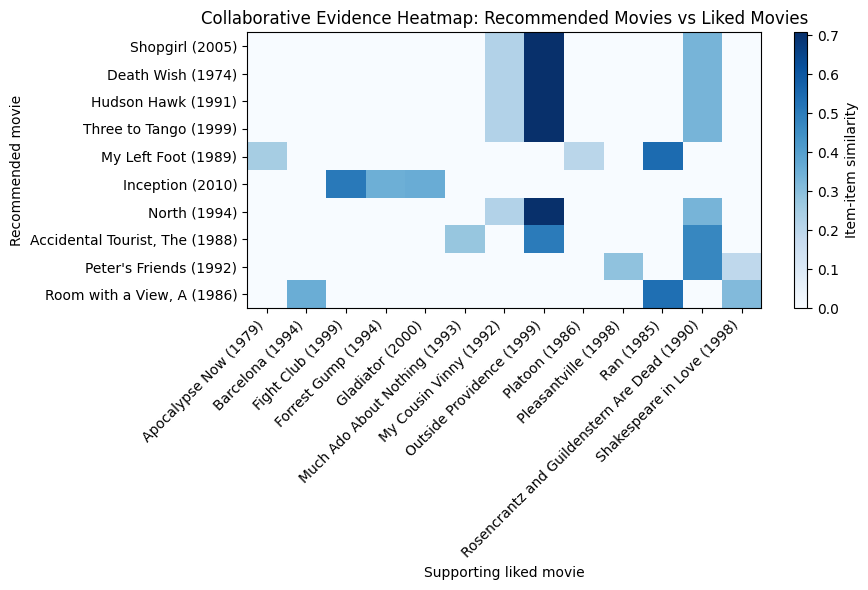

In [6]:
# Heatmap-style view: recommended movies x supporting liked movies.
evidence_heatmap = collaborative_evidence_table.pivot_table(
    index="recommended_movie",
    columns="supporting_liked_movie",
    values="similarity",
    aggfunc="max",
    fill_value=0.0,
)

# Keep only real evidence columns and order rows by recommendation rank.
evidence_heatmap = evidence_heatmap.drop(columns=["no direct KNN evidence"], errors="ignore")
rank_order = (
    collaborative_evidence_table[["recommended_movie", "recommendation_rank"]]
    .drop_duplicates()
    .sort_values("recommendation_rank")["recommended_movie"]
    .tolist()
)
evidence_heatmap = evidence_heatmap.reindex(rank_order).fillna(0.0)

if evidence_heatmap.empty or evidence_heatmap.shape[1] == 0:
    print("No collaborative evidence heatmap could be created for this user.")
else:
    fig, ax = plt.subplots(figsize=(max(9, evidence_heatmap.shape[1] * 0.7), 6))
    im = ax.imshow(evidence_heatmap.to_numpy(), aspect="auto", cmap="Blues")
    ax.set_xticks(range(evidence_heatmap.shape[1]))
    ax.set_xticklabels(evidence_heatmap.columns, rotation=45, ha="right")
    ax.set_yticks(range(evidence_heatmap.shape[0]))
    ax.set_yticklabels(evidence_heatmap.index)
    ax.set_title("Collaborative Evidence Heatmap: Recommended Movies vs Liked Movies")
    ax.set_xlabel("Supporting liked movie")
    ax.set_ylabel("Recommended movie")
    fig.colorbar(im, ax=ax, label="Item-item similarity")
    plt.tight_layout()

,supporting_liked_movie,recommendations_supported,mean_similarity,max_similarity
0,Rosencrantz and Guildenstern Are Dead (1990),7,0.3728,0.4714
1,Outside Providence (1999),6,0.6726,0.7071
2,My Cousin Vinny (1992),5,0.2182,0.2182
3,Ran (1985),2,0.5400,0.5455
4,Shakespeare in Love (1998),2,0.2527,0.3146
5,Fight Club (1999),1,0.5067,0.5067
6,Gladiator (2000),1,0.3576,0.3576
7,Barcelona (1994),1,0.3536,0.3536
8,Forrest Gump (1994),1,0.3502,0.3502
9,Pleasantville (1998),1,0.2887,0.2887


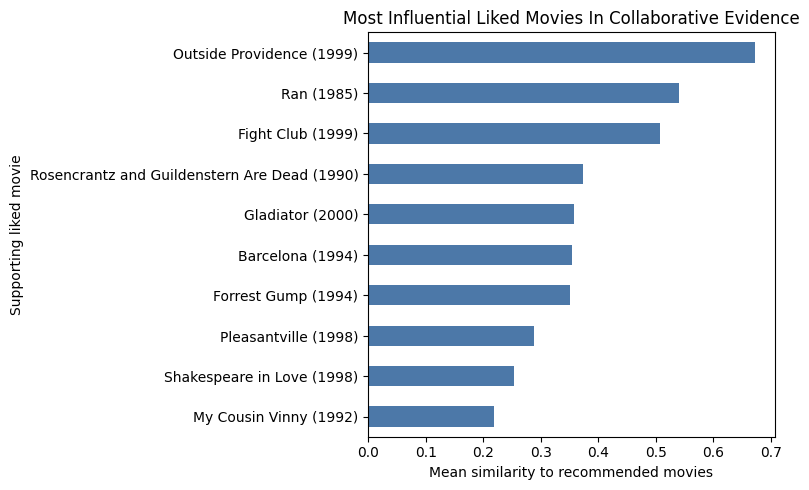

In [7]:
real_evidence = collaborative_evidence_table[
    collaborative_evidence_table["supporting_liked_movie"] != "no direct KNN evidence"
].copy()

if real_evidence.empty:
    print("No direct collaborative evidence available to aggregate.")
else:
    supporting_movie_importance = (
        real_evidence.groupby("supporting_liked_movie")
        .agg(
            recommendations_supported=("recommended_movie", "nunique"),
            mean_similarity=("similarity", "mean"),
            max_similarity=("similarity", "max"),
        )
        .sort_values(["recommendations_supported", "mean_similarity"], ascending=False)
        .reset_index()
    )
    display(supporting_movie_importance.round(4))

    ax = supporting_movie_importance.head(10).sort_values("mean_similarity").plot(
        kind="barh",
        x="supporting_liked_movie",
        y="mean_similarity",
        figsize=(8, 5),
        legend=False,
        color="#4C78A8",
    )
    ax.set_title("Most Influential Liked Movies In Collaborative Evidence")
    ax.set_xlabel("Mean similarity to recommended movies")
    ax.set_ylabel("Supporting liked movie")
    plt.tight_layout()

### 4.1 Collaborative Evidence Interpretation

This table is useful because it gives a concrete answer to the user-facing question: **"Why this movie?"**

Instead of saying only that the item-item KNN component was important, we can identify the exact liked movies responsible for the recommendation. This is more actionable and more understandable than a generic collaborative-filtering score.

## 5. Component Contributions And SHAP-Style Attributions

The hybrid ranker is a weighted additive model over structured features. This means we can explain each recommendation through exact component contributions.

SHAP-style values are also available for the same structured features:

- `item_knn_score`
- `popularity_score`
- `genre_score`

These are meaningful because the features themselves are interpretable.

,title,item_knn_contribution,popularity_contribution,genre_contribution,total_contribution,top_component
0,Shopgirl (2005),0.50000,0.142200,0.237625,0.879825,item_knn
1,Death Wish (1974),0.50000,0.152775,0.188475,0.841250,item_knn
2,Hudson Hawk (1991),0.50000,0.152775,0.159900,0.812675,item_knn
3,Three to Tango (1999),0.50000,0.149300,0.154075,0.803375,item_knn
4,My Left Foot (1989),0.38575,0.183700,0.193700,0.763150,item_knn
5,Inception (2010),0.35830,0.230000,0.172575,0.760875,item_knn
6,North (1994),0.50000,0.117600,0.143000,0.760600,item_knn
7,"Accidental Tourist, The (1988)",0.35355,0.166875,0.237625,0.758050,item_knn
8,Peter's Friends (1992),0.33335,0.170900,0.238100,0.742350,item_knn
9,"Room with a View, A (1986)",0.37795,0.174050,0.189925,0.741925,item_knn


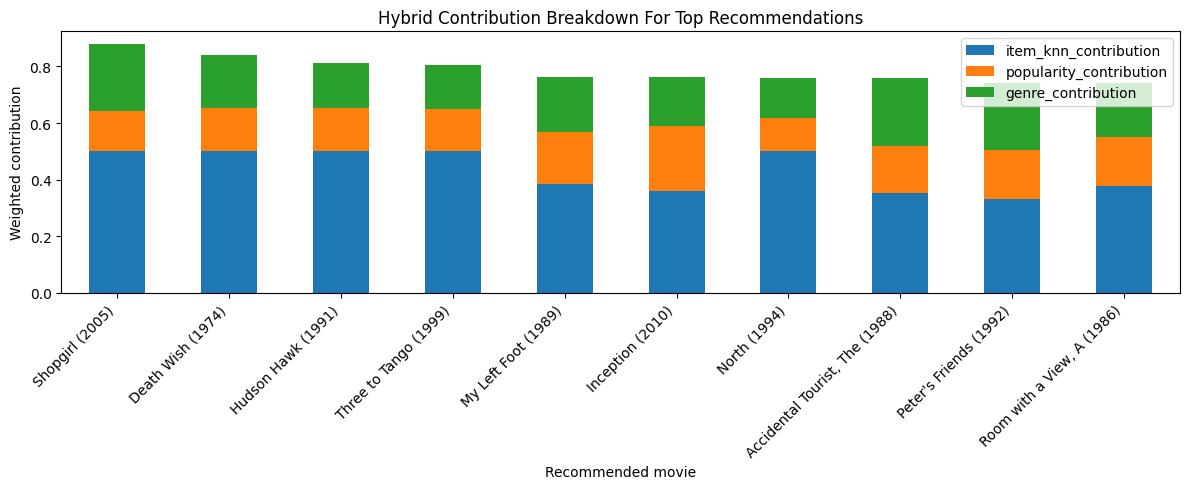

In [8]:
contribution_rows = []
for _, row in recommendations.iterrows():
    breakdown = row["component_contributions"]
    contributions = breakdown.get("contributions", {}) if isinstance(breakdown, dict) else {}
    contribution_rows.append(
        {
            "title": row["title"],
            "item_knn_contribution": contributions.get("item_knn", np.nan),
            "popularity_contribution": contributions.get("popularity", np.nan),
            "genre_contribution": contributions.get("genre", np.nan),
            "total_contribution": breakdown.get("total", np.nan) if isinstance(breakdown, dict) else np.nan,
            "top_component": breakdown.get("top_component", None) if isinstance(breakdown, dict) else None,
        }
    )

contribution_df = pd.DataFrame(contribution_rows)
display(contribution_df)

plot_df = contribution_df.set_index("title")[["item_knn_contribution", "popularity_contribution", "genre_contribution"]]
ax = plot_df.plot(kind="bar", stacked=True, figsize=(12, 5))
ax.set_title("Hybrid Contribution Breakdown For Top Recommendations")
ax.set_xlabel("Recommended movie")
ax.set_ylabel("Weighted contribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

,title,item_knn_shap,popularity_shap,genre_shap
0,Shopgirl (2005),0.50000,0.142200,0.237625
1,Death Wish (1974),0.50000,0.152775,0.188475
2,Hudson Hawk (1991),0.50000,0.152775,0.159900
3,Three to Tango (1999),0.50000,0.149300,0.154075
4,My Left Foot (1989),0.38575,0.183700,0.193700
5,Inception (2010),0.35830,0.230000,0.172575
6,North (1994),0.50000,0.117600,0.143000
7,"Accidental Tourist, The (1988)",0.35355,0.166875,0.237625
8,Peter's Friends (1992),0.33335,0.170900,0.238100
9,"Room with a View, A (1986)",0.37795,0.174050,0.189925


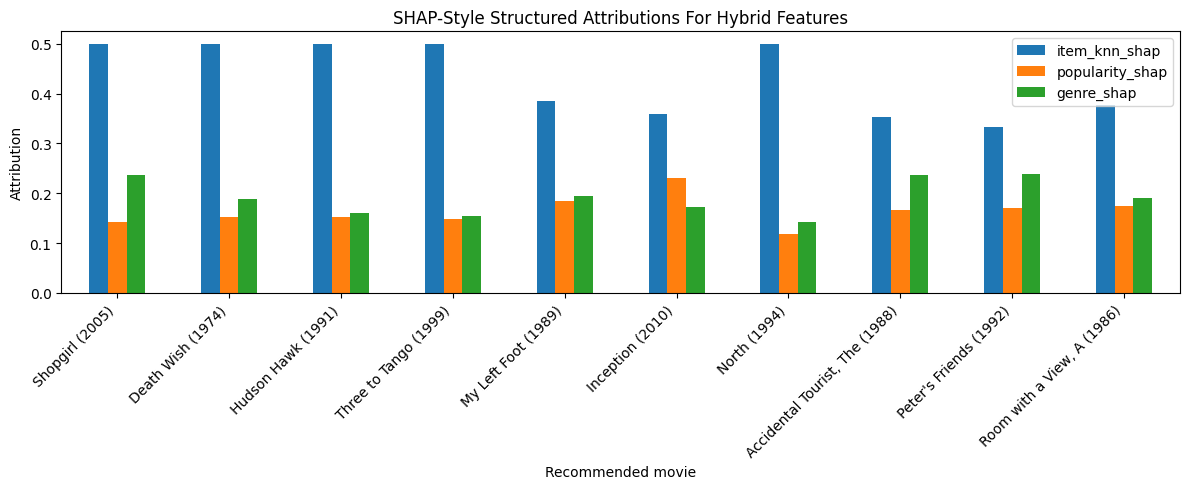

In [9]:
shap_cols = ["item_knn_shap", "popularity_shap", "genre_shap"]
shap_display = recommendations[["title"] + shap_cols].copy()
display(shap_display)

ax = shap_display.set_index("title")[shap_cols].plot(kind="bar", figsize=(12, 5))
ax.set_title("SHAP-Style Structured Attributions For Hybrid Features")
ax.set_xlabel("Recommended movie")
ax.set_ylabel("Attribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### 5.1 SHAP Force And Waterfall Plots For One Recommendation

The hybrid ranker is an additive model over three structured features. For one recommendation, the final relevance score can be explained as the sum of three SHAP-style contributions:

```text
final_score = item_knn_shap + popularity_shap + genre_shap
```

The force-style plot shows how each component pushes the score upward. The waterfall-style plot shows the same additive process step by step. These plots explain the top-level hybrid decision: whether the recommendation is mainly driven by collaborative similarity, global popularity, or genre affinity.

In [10]:
force_target = recommendations.iloc[0]
force_features = [
    ("item KNN", float(force_target["item_knn_shap"])),
    ("popularity", float(force_target["popularity_shap"])),
    ("genre", float(force_target["genre_shap"])),
]
force_total = sum(value for _, value in force_features)

force_table = pd.DataFrame(
    {
        "feature": [name for name, _ in force_features],
        "shap_value": [value for _, value in force_features],
        "feature_score": [
            float(force_target["item_knn_score"]),
            float(force_target["popularity_score"]),
            float(force_target["genre_score"]),
        ],
    }
)
force_table["share_of_final_score"] = np.where(
    force_total > 0,
    force_table["shap_value"] / force_total,
    0.0,
)

print(f"Explained recommendation: {force_target['title']}")
print(f"Final relevance score: {force_target['relevance_score']:.4f}")
display(force_table.round(4))

Explained recommendation: Shopgirl (2005)
Final relevance score: 0.8798


,feature,shap_value,feature_score,share_of_final_score
0,item KNN,0.5000,1.0000,0.5683
1,popularity,0.1422,0.5688,0.1616
2,genre,0.2376,0.9505,0.2701


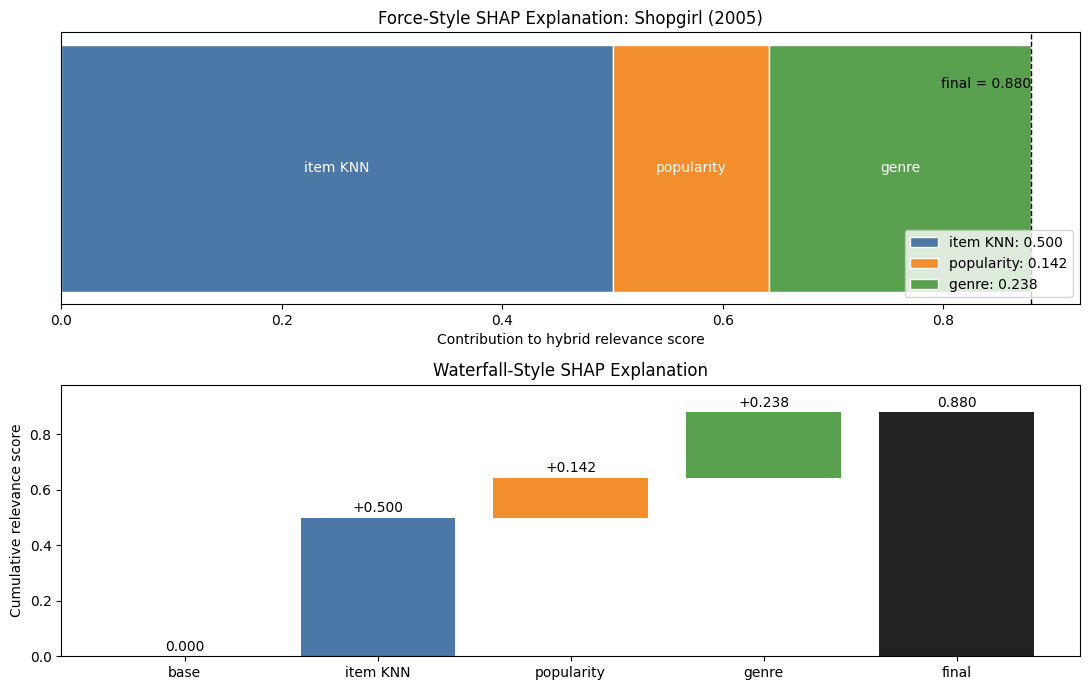

In [11]:
colors = {
    "item KNN": "#4C78A8",
    "popularity": "#F28E2B",
    "genre": "#59A14F",
}

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

# Force-style plot: all positive additive pushes toward final score.
left = 0.0
for feature, value in force_features:
    axes[0].barh(
        [0],
        [value],
        left=left,
        color=colors[feature],
        edgecolor="white",
        label=f"{feature}: {value:.3f}",
    )
    axes[0].text(left + value / 2, 0, feature, ha="center", va="center", color="white", fontsize=10)
    left += value
axes[0].axvline(force_total, color="black", linestyle="--", linewidth=1)
axes[0].text(force_total, 0.25, f"final = {force_total:.3f}", ha="right", va="bottom")
axes[0].set_title(f"Force-Style SHAP Explanation: {force_target['title']}")
axes[0].set_xlabel("Contribution to hybrid relevance score")
axes[0].set_yticks([])
axes[0].legend(loc="lower right")

# Waterfall-style plot: cumulative construction of final score.
cumulative = 0.0
x_labels = ["base"]
bar_starts = [0.0]
bar_values = [0.0]
bar_colors = ["#BAB0AC"]

for feature, value in force_features:
    x_labels.append(feature)
    bar_starts.append(cumulative)
    bar_values.append(value)
    bar_colors.append(colors[feature])
    cumulative += value

x_labels.append("final")
bar_starts.append(0.0)
bar_values.append(cumulative)
bar_colors.append("#222222")

for idx, (start, value, color) in enumerate(zip(bar_starts, bar_values, bar_colors)):
    if x_labels[idx] == "base":
        axes[1].bar(idx, 0, color=color)
        axes[1].text(idx, 0.01, "0.000", ha="center", va="bottom")
    elif x_labels[idx] == "final":
        axes[1].bar(idx, value, color=color)
        axes[1].text(idx, value + 0.01, f"{value:.3f}", ha="center", va="bottom")
    else:
        axes[1].bar(idx, value, bottom=start, color=color)
        axes[1].text(idx, start + value + 0.01, f"+{value:.3f}", ha="center", va="bottom")

axes[1].set_xticks(range(len(x_labels)))
axes[1].set_xticklabels(x_labels)
axes[1].set_title("Waterfall-Style SHAP Explanation")
axes[1].set_ylabel("Cumulative relevance score")
axes[1].set_ylim(0, max(force_total + 0.1, 0.2))

plt.tight_layout()

### 5.2 SHAP Summary Plot: Global Importance Of Hybrid Components

The force and waterfall plots explain one recommendation. A SHAP summary plot answers a broader question:

> Across many users and recommendations, which hybrid component usually contributes the most?

For the hybrid ranker, the structured SHAP-style features are:

- `item_knn_shap`
- `popularity_shap`
- `genre_shap`

Because the hybrid model is additive and uses normalized weighted scores, these values can be interpreted as exact top-level contributions to the final relevance score.

In [12]:
# Build a global explanation sample across multiple users.
summary_users = available_users[:100]
summary_rows = []

for sampled_user in summary_users:
    user_recs = ranker.recommend_for_user(sampled_user, top_n=10, diversity_weight=0.05)
    if user_recs.empty:
        continue
    user_recs = user_recs.copy()
    user_recs["userId"] = sampled_user
    summary_rows.append(user_recs)

shap_summary_sample = pd.concat(summary_rows, ignore_index=True)
shap_feature_cols = ["item_knn_shap", "popularity_shap", "genre_shap"]

shap_global_importance = (
    shap_summary_sample[shap_feature_cols]
    .abs()
    .mean()
    .sort_values(ascending=False)
    .rename("mean_abs_shap")
    .reset_index()
)
shap_global_importance.columns = ["hybrid_component", "mean_abs_shap"]

print(f"Recommendations analyzed: {len(shap_summary_sample)}")
display(shap_global_importance)

Recommendations analyzed: 1000


,hybrid_component,mean_abs_shap
0,item_knn_shap,0.428020
1,popularity_shap,0.196805
2,genre_shap,0.188604


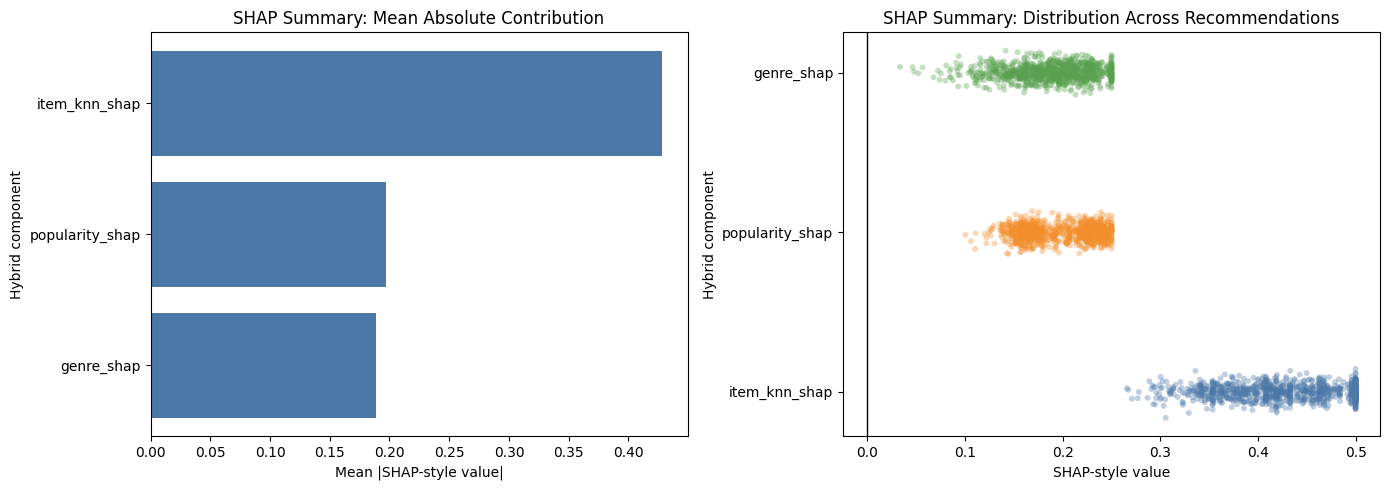

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SHAP bar summary: global component importance.
importance_plot = shap_global_importance.sort_values("mean_abs_shap", ascending=True)
axes[0].barh(
    importance_plot["hybrid_component"],
    importance_plot["mean_abs_shap"],
    color="#4C78A8",
)
axes[0].set_title("SHAP Summary: Mean Absolute Contribution")
axes[0].set_xlabel("Mean |SHAP-style value|")
axes[0].set_ylabel("Hybrid component")

# SHAP beeswarm-style strip plot using matplotlib.
component_labels = shap_feature_cols
component_colors = {
    "item_knn_shap": "#4C78A8",
    "popularity_shap": "#F28E2B",
    "genre_shap": "#59A14F",
}

rng = np.random.default_rng(42)
for y_position, col in enumerate(component_labels):
    values = shap_summary_sample[col].astype(float).to_numpy()
    jitter = rng.normal(0, 0.045, size=len(values))
    axes[1].scatter(
        values,
        np.full(len(values), y_position) + jitter,
        alpha=0.35,
        s=18,
        color=component_colors[col],
        edgecolors="none",
    )

axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_yticks(range(len(component_labels)))
axes[1].set_yticklabels(component_labels)
axes[1].set_title("SHAP Summary: Distribution Across Recommendations")
axes[1].set_xlabel("SHAP-style value")
axes[1].set_ylabel("Hybrid component")

plt.tight_layout()

In [14]:
dominant_global_component = shap_global_importance.iloc[0]

summary_insights = pd.DataFrame(
    [
        {
            "insight": "most important global hybrid component",
            "value": dominant_global_component["hybrid_component"],
            "evidence": f"mean absolute SHAP-style value = {dominant_global_component['mean_abs_shap']:.4f}",
        },
        {
            "insight": "recommendations analyzed",
            "value": len(shap_summary_sample),
            "evidence": f"{len(summary_users)} users x top 10 recommendations, excluding empty outputs",
        },
        {
            "insight": "interpretation level",
            "value": "top-level hybrid components",
            "evidence": "This explains item similarity vs popularity vs genre, not exact genres or liked movies.",
        },
    ]
)
summary_insights

,insight,value,evidence
0,most important global hybrid component,item_knn_shap,mean absolute SHAP-style value = 0.4280
1,recommendations analyzed,1000,"100 users x top 10 recommendations, excluding ..."
2,interpretation level,top-level hybrid components,This explains item similarity vs popularity vs...


## 6. Deeper Feature-Level Drill-Down

The SHAP-style hybrid explanation is useful, but it only explains the three top-level hybrid components. To understand *why* those components are high, we need to look inside each component:

- **item-item KNN:** which exact liked movies support the recommendation?
- **genre affinity:** which exact genres overlap between the user profile and the recommended movie?
- **popularity:** is the popularity score supported by many ratings, or mostly pulled from the global prior?

This is the most faithful deeper explanation because it follows the actual mechanics used by the hybrid ranker.

In [15]:
target = recommendations.iloc[0]
target_movie_id = int(target["movieId"])
print(f"Deep explanation target: {target['title']}")
print(target["explanation_summary"])

# 1. Collaborative evidence: exact liked movies used as support.
collaborative_evidence = pd.DataFrame(target["explanations"])
if not collaborative_evidence.empty:
    collaborative_evidence = collaborative_evidence.rename(
        columns={"title": "supporting_liked_movie", "similarity": "item_similarity"}
    )
    display(collaborative_evidence[["movieId", "supporting_liked_movie", "item_similarity"]])
else:
    print("No collaborative evidence available for this recommendation.")

# 2. Genre-level decomposition: exact genres driving genre affinity.
user_profile = ranker.user_genre_profiles[demo_user]
item_genre_vector = ranker.item_engine.movies.loc[target_movie_id, ranker.item_engine.genre_cols].to_numpy(dtype=np.float32)
genre_breakdown = genre_affinity_breakdown(
    user_profile,
    item_genre_vector,
    ranker.item_engine.genre_cols,
    top_n=10,
)
print("Genre affinity breakdown:")
display(genre_breakdown)

# 3. Popularity-level decomposition: Bayesian score support.
popularity_breakdown = pd.DataFrame([
    bayesian_popularity_breakdown(target_movie_id, ranker.item_engine.train_df, smoothing=10)
])
print("Bayesian popularity breakdown:")
display(popularity_breakdown.round(4))

Deep explanation target: Shopgirl (2005)
Main signal: similarity to movies the user liked.


,movieId,supporting_liked_movie,item_similarity
0,2836,Outside Providence (1999),0.707107
1,1243,Rosencrantz and Guildenstern Are Dead (1990),0.333333
2,2302,My Cousin Vinny (1992),0.218218


Genre affinity breakdown:


,genre,user_profile_strength,item_has_genre,contribution
0,Drama,0.659272,1.0,0.380631
1,Comedy,0.486684,1.0,0.280987
2,Romance,0.254858,1.0,0.147142


Bayesian popularity breakdown:


,movieId,movie_mean_rating,rating_count,global_mean_rating,smoothing,movie_data_weight,global_prior_weight,bayesian_popularity_score
0,39414,2.9,5,3.5141,10,0.3333,0.6667,3.3094


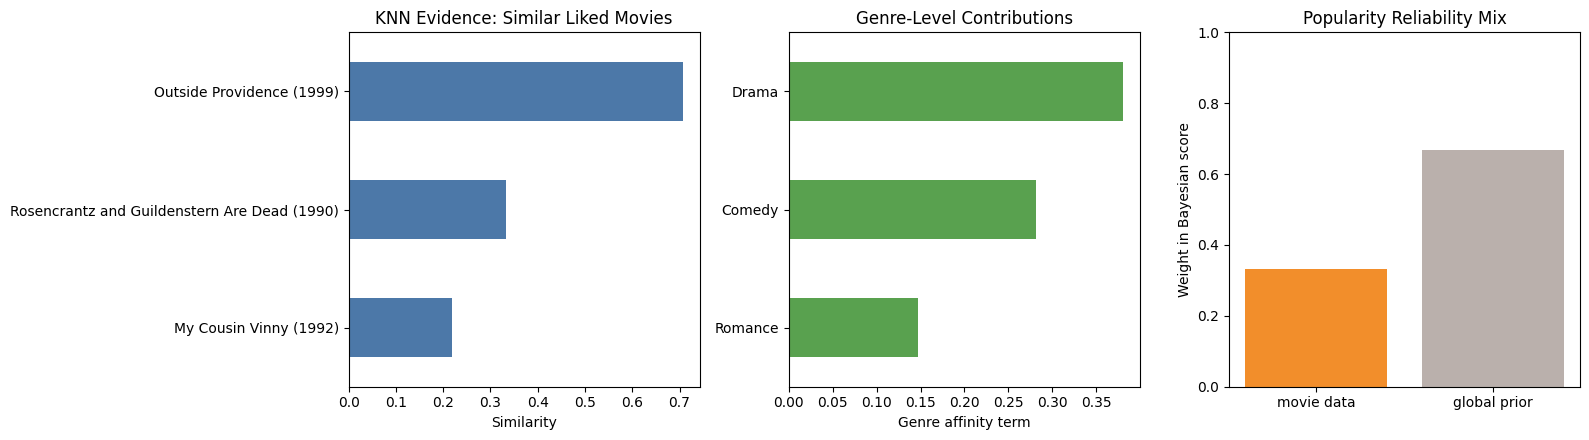

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

if not collaborative_evidence.empty:
    collaborative_evidence.sort_values("item_similarity").plot(
        kind="barh",
        x="supporting_liked_movie",
        y="item_similarity",
        ax=axes[0],
        legend=False,
        color="#4C78A8",
    )
    axes[0].set_title("KNN Evidence: Similar Liked Movies")
    axes[0].set_xlabel("Similarity")
    axes[0].set_ylabel("")
else:
    axes[0].text(0.5, 0.5, "No KNN evidence", ha="center", va="center")
    axes[0].set_axis_off()

if not genre_breakdown.empty:
    genre_breakdown.sort_values("contribution").plot(
        kind="barh",
        x="genre",
        y="contribution",
        ax=axes[1],
        legend=False,
        color="#59A14F",
    )
    axes[1].set_title("Genre-Level Contributions")
    axes[1].set_xlabel("Genre affinity term")
    axes[1].set_ylabel("")
else:
    axes[1].text(0.5, 0.5, "No active genres", ha="center", va="center")
    axes[1].set_axis_off()

pop = popularity_breakdown.iloc[0]
axes[2].bar(
    ["movie data", "global prior"],
    [pop["movie_data_weight"], pop["global_prior_weight"]],
    color=["#F28E2B", "#BAB0AC"],
)
axes[2].set_title("Popularity Reliability Mix")
axes[2].set_ylabel("Weight in Bayesian score")
axes[2].set_ylim(0, 1)

plt.tight_layout()

In [17]:
deep_insights = []

if not collaborative_evidence.empty:
    best_support = collaborative_evidence.sort_values("item_similarity", ascending=False).iloc[0]
    deep_insights.append(
        {
            "question": "Which liked movie most supports this recommendation?",
            "answer": best_support["supporting_liked_movie"],
            "evidence": f"item similarity = {best_support['item_similarity']:.3f}",
        }
    )

if not genre_breakdown.empty:
    best_genre = genre_breakdown.iloc[0]
    deep_insights.append(
        {
            "question": "Which exact genre contributes most?",
            "answer": best_genre["genre"],
            "evidence": f"genre contribution = {best_genre['contribution']:.3f}",
        }
    )

pop = popularity_breakdown.iloc[0]
deep_insights.append(
    {
        "question": "Is the popularity score reliable?",
        "answer": "more data-driven" if pop["movie_data_weight"] >= pop["global_prior_weight"] else "more prior-driven",
        "evidence": f"{int(pop['rating_count'])} ratings, movie-data weight = {pop['movie_data_weight']:.2f}",
    }
)

pd.DataFrame(deep_insights)

,question,answer,evidence
0,Which liked movie most supports this recommend...,Outside Providence (1999),item similarity = 0.707
1,Which exact genre contributes most?,Drama,genre contribution = 0.381
2,Is the popularity score reliable?,more prior-driven,"5 ratings, movie-data weight = 0.33"


## 7. Genre Contribution Plot: Exact Genre Drivers

The previous SHAP plots explain whether the **genre component** matters. This section goes one level deeper and asks:

> Which exact genres are responsible for the genre component?

The genre affinity score is based on the overlap between the user's learned genre profile and the candidate movie's active genres. Therefore, the exact genre contribution can be decomposed into individual genre terms.

Genre drivers for: Shopgirl (2005)


,genre,user_profile_strength,item_has_genre,contribution
0,Drama,0.659272,1.0,0.380631
1,Comedy,0.486684,1.0,0.280987
2,Romance,0.254858,1.0,0.147142


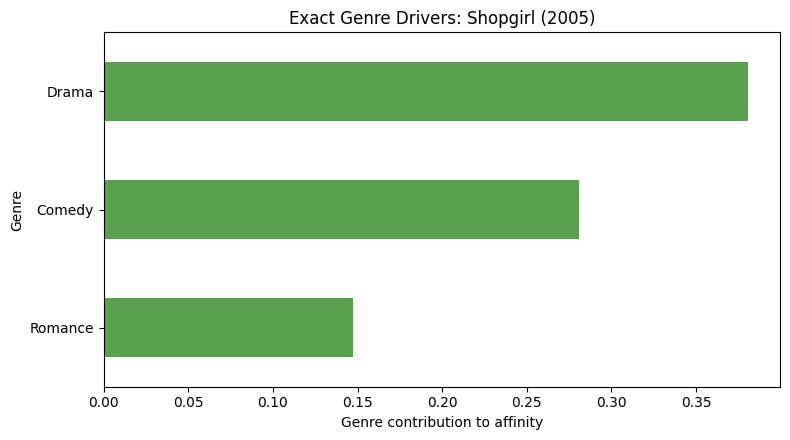

In [18]:
# Local exact genre drivers for the top recommendation.
genre_target = recommendations.iloc[0]
genre_target_movie_id = int(genre_target["movieId"])

user_profile = ranker.user_genre_profiles[demo_user]
item_genre_vector = ranker.item_engine.movies.loc[
    genre_target_movie_id,
    ranker.item_engine.genre_cols,
].to_numpy(dtype=np.float32)

target_genre_breakdown = genre_affinity_breakdown(
    user_profile,
    item_genre_vector,
    ranker.item_engine.genre_cols,
    top_n=10,
)

print(f"Genre drivers for: {genre_target['title']}")
display(target_genre_breakdown)

if not target_genre_breakdown.empty:
    ax = target_genre_breakdown.sort_values("contribution").plot(
        kind="barh",
        x="genre",
        y="contribution",
        figsize=(8, 4.5),
        legend=False,
        color="#59A14F",
    )
    ax.set_title(f"Exact Genre Drivers: {genre_target['title']}")
    ax.set_xlabel("Genre contribution to affinity")
    ax.set_ylabel("Genre")
    plt.tight_layout()
else:
    print("No active genres available for this recommendation.")

,Drama,Comedy,Romance,Action,Crime,Adventure,Thriller,Sci-Fi,Mystery,IMAX
title,,,,,,,,,,
Shopgirl (2005),0.3806,0.2810,0.1471,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
Death Wish (1974),0.3806,0.0000,0.0000,0.1442,0.1166,0.0000,0.000,0.0000,0.0000,0.0000
Hudson Hawk (1991),0.0000,0.2810,0.0000,0.1442,0.0000,0.1191,0.000,0.0000,0.0000,0.0000
Three to Tango (1999),0.0000,0.3441,0.1802,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
My Left Foot (1989),0.6593,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
Inception (2010),0.2492,0.0000,0.0000,0.0944,0.0764,0.0000,0.086,0.0473,0.0303,0.0039
North (1994),0.0000,0.4867,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
"Accidental Tourist, The (1988)",0.3806,0.2810,0.1471,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000
Peter's Friends (1992),0.4662,0.3441,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000


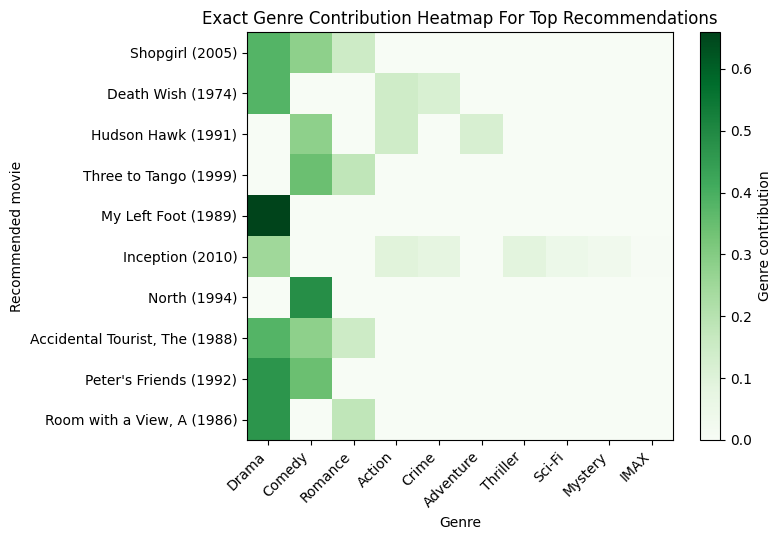

In [19]:
# Genre contribution matrix for the demo user's top recommendations.
genre_matrix_rows = []
for _, rec in recommendations.head(10).iterrows():
    movie_id = int(rec["movieId"])
    item_vector = ranker.item_engine.movies.loc[movie_id, ranker.item_engine.genre_cols].to_numpy(dtype=np.float32)
    breakdown = genre_affinity_breakdown(
        user_profile,
        item_vector,
        ranker.item_engine.genre_cols,
        top_n=len(ranker.item_engine.genre_cols),
    )
    row = {"title": rec["title"]}
    for _, genre_row in breakdown.iterrows():
        row[genre_row["genre"]] = genre_row["contribution"]
    genre_matrix_rows.append(row)

genre_contribution_matrix = pd.DataFrame(genre_matrix_rows).fillna(0.0).set_index("title")
active_genre_cols = genre_contribution_matrix.sum(axis=0).sort_values(ascending=False)
active_genre_cols = active_genre_cols[active_genre_cols > 0].index.tolist()

display(genre_contribution_matrix[active_genre_cols].round(4))

fig, ax = plt.subplots(figsize=(max(8, len(active_genre_cols) * 0.7), 5.5))
im = ax.imshow(genre_contribution_matrix[active_genre_cols].to_numpy(), aspect="auto", cmap="Greens")
ax.set_xticks(range(len(active_genre_cols)))
ax.set_xticklabels(active_genre_cols, rotation=45, ha="right")
ax.set_yticks(range(len(genre_contribution_matrix.index)))
ax.set_yticklabels(genre_contribution_matrix.index)
ax.set_title("Exact Genre Contribution Heatmap For Top Recommendations")
ax.set_xlabel("Genre")
ax.set_ylabel("Recommended movie")
fig.colorbar(im, ax=ax, label="Genre contribution")
plt.tight_layout()

,genre,total_contribution,mean_contribution,appearances
0,Drama,30.2861,0.3403,89
1,Action,17.5845,0.2477,71
2,Comedy,12.3727,0.2334,53
3,Adventure,11.5116,0.2172,53
4,Thriller,9.3782,0.1839,51
5,Crime,6.1509,0.1538,40
6,Sci-Fi,5.0453,0.1682,30
7,Romance,4.2352,0.1841,23
8,War,1.0244,0.0931,11
9,Children,0.8355,0.1044,8


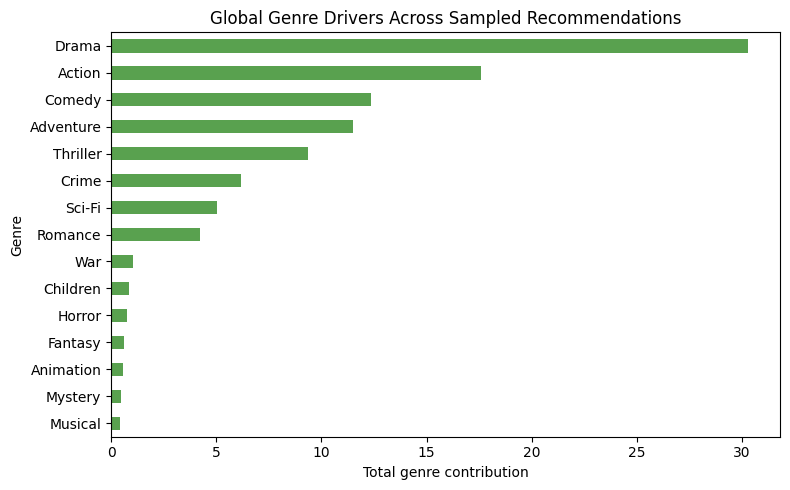

In [20]:
# Global exact genre drivers across a sampled group of users.
# Kept intentionally smaller than the full dataset so the notebook remains practical.
genre_sample_users = available_users[:30]
global_genre_rows = []

for sampled_user in genre_sample_users:
    profile = ranker.user_genre_profiles.get(sampled_user)
    if profile is None:
        continue
    sampled_recs = ranker.recommend_for_user(sampled_user, top_n=5, diversity_weight=0.05)
    for _, rec in sampled_recs.iterrows():
        movie_id = int(rec["movieId"])
        item_vector = ranker.item_engine.movies.loc[movie_id, ranker.item_engine.genre_cols].to_numpy(dtype=np.float32)
        breakdown = genre_affinity_breakdown(
            profile,
            item_vector,
            ranker.item_engine.genre_cols,
            top_n=len(ranker.item_engine.genre_cols),
        )
        for _, genre_row in breakdown.iterrows():
            global_genre_rows.append(
                {
                    "userId": sampled_user,
                    "title": rec["title"],
                    "genre": genre_row["genre"],
                    "contribution": genre_row["contribution"],
                }
            )

global_genre_contributions = pd.DataFrame(global_genre_rows)

global_genre_importance = (
    global_genre_contributions.groupby("genre")["contribution"]
    .agg(total_contribution="sum", mean_contribution="mean", appearances="count")
    .sort_values("total_contribution", ascending=False)
    .reset_index()
)

display(global_genre_importance.head(15).round(4))

ax = global_genre_importance.head(15).sort_values("total_contribution").plot(
    kind="barh",
    x="genre",
    y="total_contribution",
    figsize=(8, 5),
    legend=False,
    color="#59A14F",
)
ax.set_title("Global Genre Drivers Across Sampled Recommendations")
ax.set_xlabel("Total genre contribution")
ax.set_ylabel("Genre")
plt.tight_layout()

## 8. Popularity Breakdown: Rating Count vs Global Prior

The hybrid ranker uses Bayesian-smoothed popularity rather than raw average rating. This matters because a movie with a very high average rating but only a few ratings should not be trusted as much as a movie with a high average rating and many ratings.

The Bayesian popularity score combines:

- the movie's own mean rating
- the number of ratings for that movie
- the global mean rating
- a smoothing constant

This section explains whether the popularity component for each recommendation is supported mostly by the movie's own rating data or mostly by the global prior.

In [21]:
popularity_rows = []
for rank, (_, rec) in enumerate(recommendations.iterrows(), start=1):
    breakdown = bayesian_popularity_breakdown(
        int(rec["movieId"]),
        ranker.item_engine.train_df,
        smoothing=10,
    )
    breakdown.update(
        {
            "recommendation_rank": rank,
            "title": rec["title"],
            "popularity_score_normalized": rec["popularity_score"],
            "relevance_score": rec["relevance_score"],
        }
    )
    popularity_rows.append(breakdown)

popularity_breakdowns = pd.DataFrame(popularity_rows)
popularity_breakdowns["popularity_reliability"] = np.where(
    popularity_breakdowns["movie_data_weight"] >= popularity_breakdowns["global_prior_weight"],
    "mostly movie-data driven",
    "mostly prior-driven",
)

display_cols = [
    "recommendation_rank",
    "title",
    "movie_mean_rating",
    "rating_count",
    "global_mean_rating",
    "movie_data_weight",
    "global_prior_weight",
    "bayesian_popularity_score",
    "popularity_score_normalized",
    "popularity_reliability",
]

display(popularity_breakdowns[display_cols].round(4))

,recommendation_rank,title,movie_mean_rating,rating_count,global_mean_rating,movie_data_weight,global_prior_weight,bayesian_popularity_score,popularity_score_normalized,popularity_reliability
0,1,Shopgirl (2005),2.9000,5,3.5141,0.3333,0.6667,3.3094,0.5688,mostly prior-driven
1,2,Death Wish (1974),3.0000,3,3.5141,0.2308,0.7692,3.3955,0.6111,mostly prior-driven
2,3,Hudson Hawk (1991),3.0000,3,3.5141,0.2308,0.7692,3.3955,0.6111,mostly prior-driven
3,4,Three to Tango (1999),3.0000,4,3.5141,0.2857,0.7143,3.3672,0.5972,mostly prior-driven
4,5,My Left Foot (1989),3.8125,8,3.5141,0.4444,0.5556,3.6467,0.7348,mostly prior-driven
5,6,Inception (2010),4.0640,125,3.5141,0.9259,0.0741,4.0233,0.9200,mostly movie-data driven
6,7,North (1994),2.3000,5,3.5141,0.3333,0.6667,3.1094,0.4704,mostly prior-driven
7,8,"Accidental Tourist, The (1988)",3.5000,4,3.5141,0.2857,0.7143,3.5101,0.6675,mostly prior-driven
8,9,Peter's Friends (1992),3.6000,5,3.5141,0.3333,0.6667,3.5427,0.6836,mostly prior-driven
9,10,"Room with a View, A (1986)",3.6071,14,3.5141,0.5833,0.4167,3.5684,0.6962,mostly movie-data driven


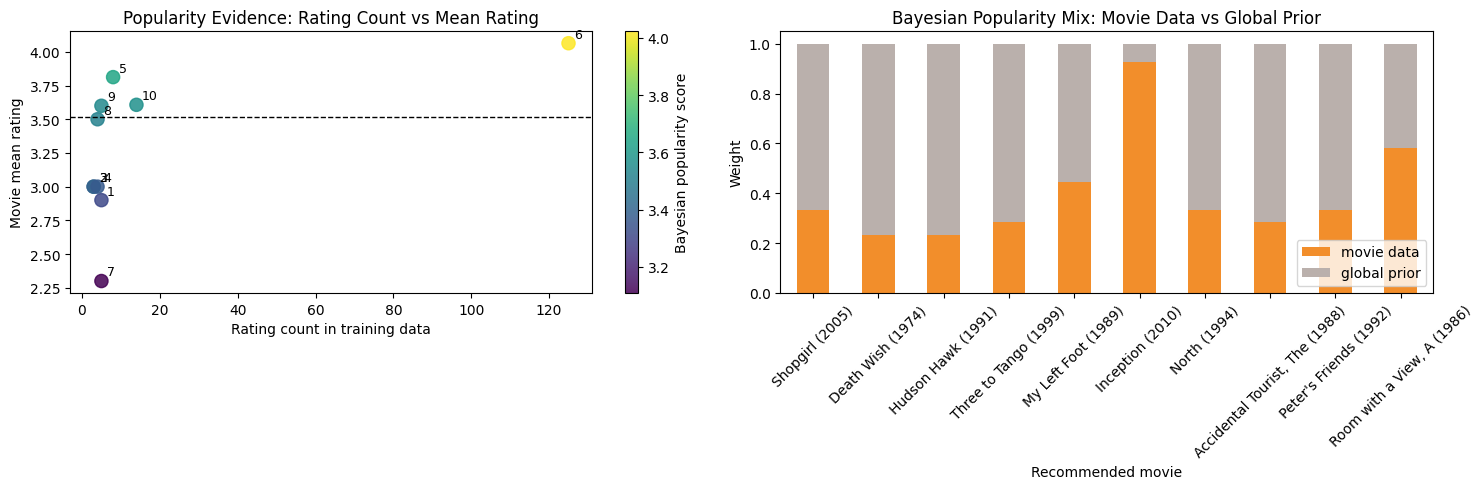

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Rating count vs mean rating explains how much evidence each movie has.
scatter = axes[0].scatter(
    popularity_breakdowns["rating_count"],
    popularity_breakdowns["movie_mean_rating"],
    c=popularity_breakdowns["bayesian_popularity_score"],
    cmap="viridis",
    s=90,
    alpha=0.85,
)
for _, row in popularity_breakdowns.iterrows():
    axes[0].annotate(
        str(int(row["recommendation_rank"])),
        (row["rating_count"], row["movie_mean_rating"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=9,
    )
axes[0].axhline(popularity_breakdowns["global_mean_rating"].iloc[0], color="black", linestyle="--", linewidth=1)
axes[0].set_title("Popularity Evidence: Rating Count vs Mean Rating")
axes[0].set_xlabel("Rating count in training data")
axes[0].set_ylabel("Movie mean rating")
fig.colorbar(scatter, ax=axes[0], label="Bayesian popularity score")

# Prior vs data mix for each recommendation.
mix_df = popularity_breakdowns.set_index("title")[["movie_data_weight", "global_prior_weight"]]
mix_df.plot(kind="bar", stacked=True, ax=axes[1], color=["#F28E2B", "#BAB0AC"])
axes[1].set_title("Bayesian Popularity Mix: Movie Data vs Global Prior")
axes[1].set_xlabel("Recommended movie")
axes[1].set_ylabel("Weight")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(["movie data", "global prior"], loc="lower right")

plt.tight_layout()

In [23]:
popularity_insights = pd.DataFrame(
    [
        {
            "insight": "most data-supported recommendation",
            "movie": popularity_breakdowns.sort_values("movie_data_weight", ascending=False).iloc[0]["title"],
            "evidence": f"rating count = {int(popularity_breakdowns.sort_values('movie_data_weight', ascending=False).iloc[0]['rating_count'])}",
        },
        {
            "insight": "highest Bayesian popularity score",
            "movie": popularity_breakdowns.sort_values("bayesian_popularity_score", ascending=False).iloc[0]["title"],
            "evidence": f"score = {popularity_breakdowns.sort_values('bayesian_popularity_score', ascending=False).iloc[0]['bayesian_popularity_score']:.3f}",
        },
        {
            "insight": "most prior-driven recommendation",
            "movie": popularity_breakdowns.sort_values("global_prior_weight", ascending=False).iloc[0]["title"],
            "evidence": f"global prior weight = {popularity_breakdowns.sort_values('global_prior_weight', ascending=False).iloc[0]['global_prior_weight']:.3f}",
        },
    ]
)
popularity_insights

,insight,movie,evidence
0,most data-supported recommendation,Inception (2010),rating count = 125
1,highest Bayesian popularity score,Inception (2010),score = 4.023
2,most prior-driven recommendation,Death Wish (1974),global prior weight = 0.769


## 9. User Genre Profile

The genre component compares candidate movie genres with the user's learned genre profile. This section shows which genres are strongest for the selected user and how the recommended movies align with that profile.

,genre,profile_strength
8,Drama,0.659272
5,Comedy,0.486684
15,Romance,0.254858
1,Action,0.249724
17,Thriller,0.227419
2,Adventure,0.206202
6,Crime,0.202012
16,Sci-Fi,0.125262
9,Fantasy,0.115961
18,War,0.096440


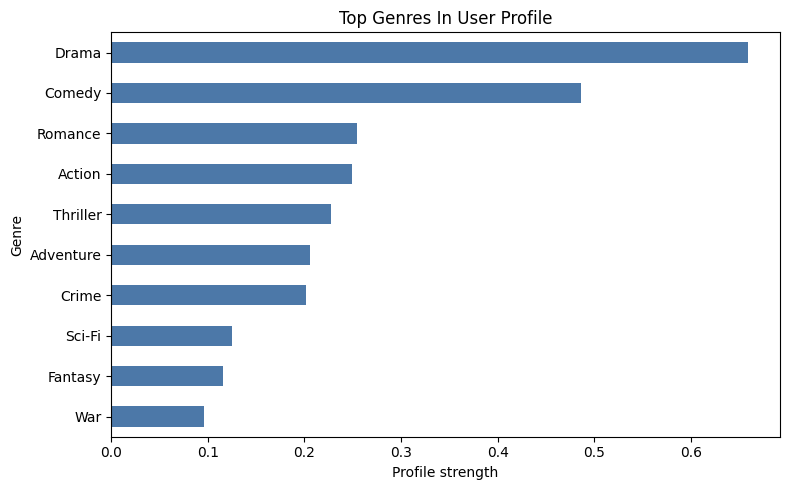

In [24]:
genre_cols = ranker.item_engine.genre_cols
profile = ranker.user_genre_profiles.get(demo_user)

if profile is None:
    print("No genre profile available for this user.")
else:
    profile_df = pd.DataFrame({"genre": genre_cols, "profile_strength": profile})
    profile_df = profile_df.sort_values("profile_strength", ascending=False)
    display(profile_df.head(10))

    ax = profile_df.head(10).sort_values("profile_strength").plot(
        kind="barh", x="genre", y="profile_strength", legend=False, figsize=(8, 5), color="#4C78A8"
    )
    ax.set_title("Top Genres In User Profile")
    ax.set_xlabel("Profile strength")
    ax.set_ylabel("Genre")
    plt.tight_layout()

## 10. Global Explanation Across Users

A global explanation asks: **Which signals usually drive the model across many users?**

We generate recommendations for a sample of users and aggregate the dominant explanation component.

,userId,title,item_knn_score,popularity_score,genre_score,top_component,item_knn_contribution,popularity_contribution,genre_contribution
0,1,For Your Eyes Only (1981),1.0000,0.5885,0.7836,item_knn,0.50000,0.147125,0.195900
1,1,"Lord of the Rings: The Return of the King, The...",0.6982,0.8680,0.8713,item_knn,0.34910,0.217000,0.217825
2,1,"Spy Who Loved Me, The (1977)",0.8839,0.5968,0.7836,item_knn,0.44195,0.149200,0.195900
3,1,Licence to Kill (1989),0.8944,0.5449,0.7836,item_knn,0.44720,0.136225,0.195900
4,1,Austin Powers: The Spy Who Shagged Me (1999),0.8291,0.4970,0.8917,item_knn,0.41455,0.124250,0.222925


,top_component,share
0,item_knn,1.0


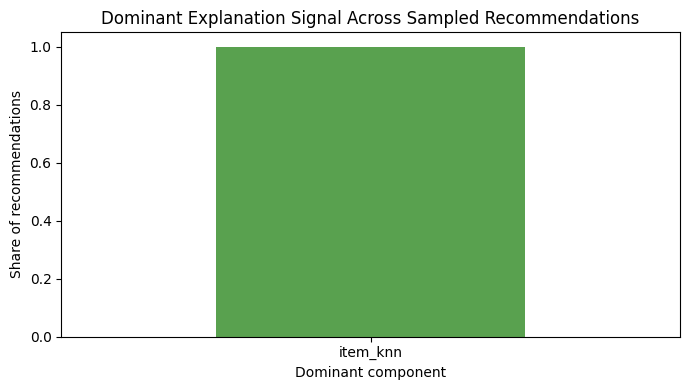

In [25]:
sample_users = available_users[:50]
global_rows = []

for user_id in sample_users:
    user_recs = ranker.recommend_for_user(user_id, top_n=10, diversity_weight=0.05)
    for _, rec in user_recs.iterrows():
        breakdown = rec["component_contributions"]
        contributions = breakdown.get("contributions", {}) if isinstance(breakdown, dict) else {}
        global_rows.append(
            {
                "userId": user_id,
                "title": rec["title"],
                "item_knn_score": rec["item_knn_score"],
                "popularity_score": rec["popularity_score"],
                "genre_score": rec["genre_score"],
                "top_component": breakdown.get("top_component", None) if isinstance(breakdown, dict) else None,
                "item_knn_contribution": contributions.get("item_knn", np.nan),
                "popularity_contribution": contributions.get("popularity", np.nan),
                "genre_contribution": contributions.get("genre", np.nan),
            }
        )

global_explanations = pd.DataFrame(global_rows)

display(global_explanations.head())

dominance = global_explanations["top_component"].value_counts(normalize=True).rename("share").reset_index()
dominance.columns = ["top_component", "share"]
display(dominance)

ax = dominance.plot(kind="bar", x="top_component", y="share", legend=False, figsize=(7, 4), color="#59A14F")
ax.set_title("Dominant Explanation Signal Across Sampled Recommendations")
ax.set_xlabel("Dominant component")
ax.set_ylabel("Share of recommendations")
plt.xticks(rotation=0)
plt.tight_layout()

,component,mean_weighted_contribution
0,item_knn_contribution,0.434983
1,popularity_contribution,0.196601
2,genre_contribution,0.187969


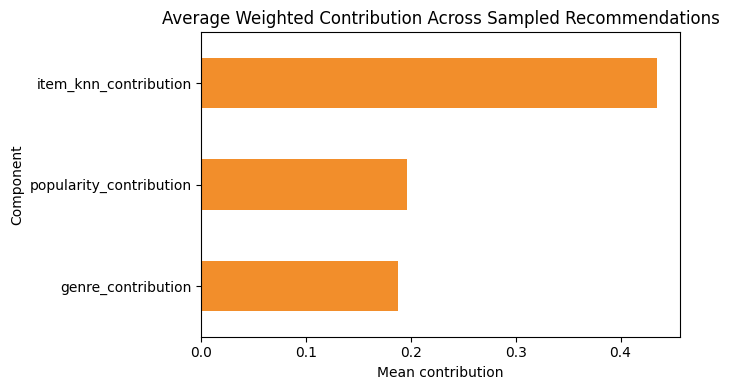

In [26]:
component_means = global_explanations[[
    "item_knn_contribution", "popularity_contribution", "genre_contribution"
]].mean().sort_values(ascending=False)

component_means_df = component_means.rename("mean_weighted_contribution").reset_index()
component_means_df.columns = ["component", "mean_weighted_contribution"]
display(component_means_df)

ax = component_means.sort_values().plot(kind="barh", figsize=(7, 4), color="#F28E2B")
ax.set_title("Average Weighted Contribution Across Sampled Recommendations")
ax.set_xlabel("Mean contribution")
ax.set_ylabel("Component")
plt.tight_layout()

## 11. Counterfactual Explanations

Counterfactual explanations ask: **How would recommendations change if the model weights or diversity setting changed?**

This is useful because it shows whether the final recommendation list is stable or strongly dependent on one modeling assumption. In this section we test two kinds of counterfactuals:

1. changing the hybrid weights between item similarity, popularity, and genre affinity
2. changing the diversity penalty

The goal is not to choose new final weights here, but to understand how sensitive the recommendation logic is.

In [27]:
weight_scenarios = {
    "default_hybrid": {"item_knn": 0.50, "popularity": 0.25, "genre": 0.25},
    "collaborative_heavy": {"item_knn": 0.80, "popularity": 0.10, "genre": 0.10},
    "popularity_heavy": {"item_knn": 0.20, "popularity": 0.70, "genre": 0.10},
    "genre_heavy": {"item_knn": 0.20, "popularity": 0.10, "genre": 0.70},
}
scenario_order = list(weight_scenarios.keys())

scenario_rows = []
scenario_recommendations = {}
for scenario_name, weights in weight_scenarios.items():
    scenario_recs = ranker.recommend_for_user(demo_user, top_n=10, weights=weights, diversity_weight=0.05)
    scenario_recommendations[scenario_name] = scenario_recs
    for rank, (_, row) in enumerate(scenario_recs.iterrows(), start=1):
        scenario_rows.append(
            {
                "scenario": scenario_name,
                "rank": rank,
                "movieId": int(row["movieId"]),
                "title": row["title"],
                "relevance_score": row["relevance_score"],
                "item_knn_score": row["item_knn_score"],
                "popularity_score": row["popularity_score"],
                "genre_score": row["genre_score"],
            }
        )

scenario_df = pd.DataFrame(scenario_rows)
print("Top-10 recommendations under different weighting assumptions:")
display(scenario_df.pivot(index="rank", columns="scenario", values="title"))

# Overlap with the default hybrid ranking.
def top_k_set(scenario_name, k):
    return set(scenario_recommendations[scenario_name]["movieId"].head(k))

def jaccard(a, b):
    return len(a & b) / len(a | b) if a | b else 0.0

def rank_overlap(a, b):
    return len(a & b)

default_top5 = top_k_set("default_hybrid", 5)
default_top10 = top_k_set("default_hybrid", 10)

overlap_rows = []
for scenario_name in scenario_order:
    top5 = top_k_set(scenario_name, 5)
    top10 = top_k_set(scenario_name, 10)
    overlap_rows.append(
        {
            "scenario": scenario_name,
            "top5_overlap_with_default": rank_overlap(default_top5, top5),
            "top5_jaccard_with_default": jaccard(default_top5, top5),
            "top10_overlap_with_default": rank_overlap(default_top10, top10),
            "top10_jaccard_with_default": jaccard(default_top10, top10),
        }
    )

overlap_df = pd.DataFrame(overlap_rows)
print("Ranking overlap with default hybrid:")
display(overlap_df.round(3))

Top-10 recommendations under different weighting assumptions:


scenario,collaborative_heavy,default_hybrid,genre_heavy,popularity_heavy
rank,,,,
1,Shopgirl (2005),Shopgirl (2005),Shopgirl (2005),"Dark Knight, The (2008)"
2,Death Wish (1974),Death Wish (1974),"Stunt Man, The (1980)","Philadelphia Story, The (1940)"
3,Hudson Hawk (1991),Hudson Hawk (1991),Peter's Friends (1992),Seven Samurai (Shichinin no samurai) (1954)
4,Three to Tango (1999),Three to Tango (1999),"Accidental Tourist, The (1988)",Inglourious Basterds (2009)
5,North (1994),My Left Foot (1989),Being There (1979),Inception (2010)
6,"Exorcist III, The (1990)",Inception (2010),Next Stop Wonderland (1998),Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)
7,Freddy Got Fingered (2001),North (1994),Cookie's Fortune (1999),Life Is Beautiful (La Vita è bella) (1997)
8,Lord of Illusions (1995),"Accidental Tourist, The (1988)",Manhattan (1979),12 Angry Men (1957)
9,My Left Foot (1989),Peter's Friends (1992),"Philadelphia Story, The (1940)",High Noon (1952)


Ranking overlap with default hybrid:


,scenario,top5_overlap_with_default,top5_jaccard_with_default,top10_overlap_with_default,top10_jaccard_with_default
0,default_hybrid,5,1.000,10,1.000
1,collaborative_heavy,4,0.667,7,0.538
2,popularity_heavy,0,0.000,1,0.053
3,genre_heavy,1,0.111,3,0.176


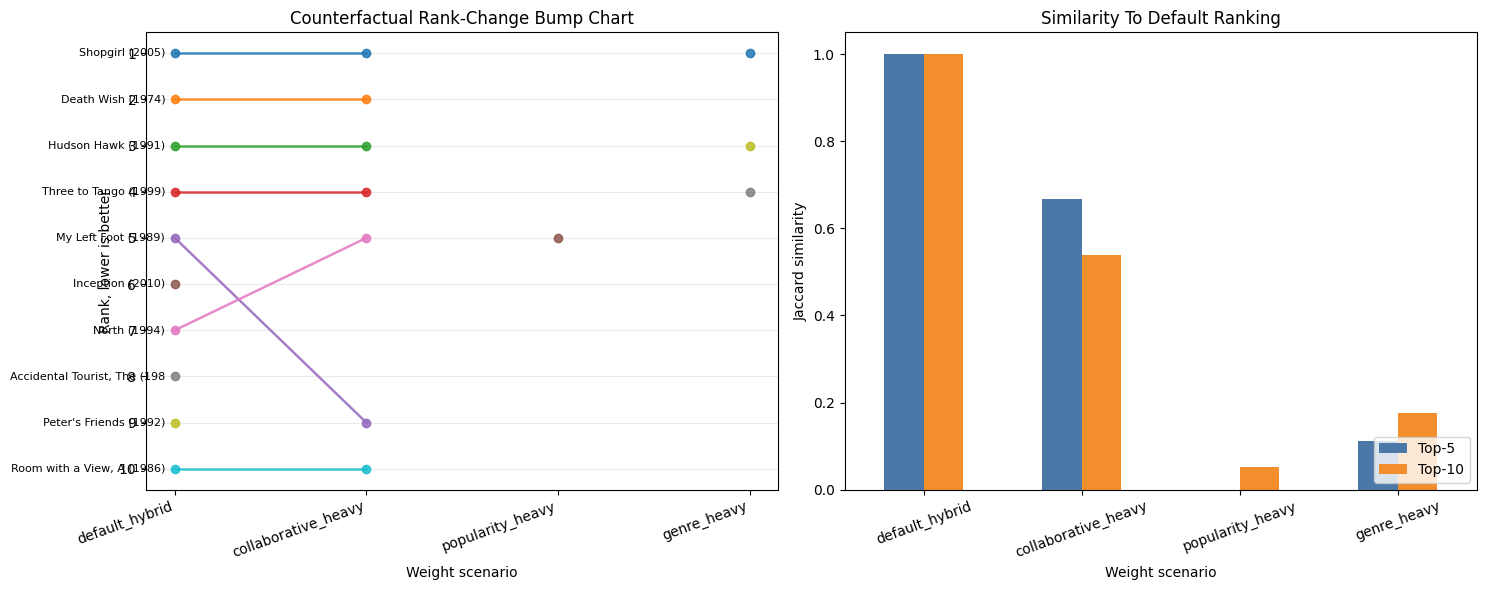

In [28]:
# Counterfactual rank-change bump chart.
default_titles = scenario_df.loc[scenario_df["scenario"] == "default_hybrid", "title"].head(10).tolist()
rank_matrix = scenario_df.pivot_table(index="title", columns="scenario", values="rank", aggfunc="min")
rank_matrix = rank_matrix.reindex(default_titles)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

x_positions = np.arange(len(scenario_order))
for title, row in rank_matrix.iterrows():
    y_values = [row.get(scenario, np.nan) for scenario in scenario_order]
    axes[0].plot(x_positions, y_values, marker="o", linewidth=1.8, alpha=0.85)
    if not np.isnan(y_values[0]):
        axes[0].text(x_positions[0] - 0.05, y_values[0], title[:28], ha="right", va="center", fontsize=8)

axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(scenario_order, rotation=20, ha="right")
axes[0].invert_yaxis()
axes[0].set_yticks(range(1, 11))
axes[0].set_title("Counterfactual Rank-Change Bump Chart")
axes[0].set_xlabel("Weight scenario")
axes[0].set_ylabel("Rank, lower is better")
axes[0].grid(axis="y", alpha=0.25)

# Overlap plot: how much each scenario preserves the default list.
overlap_plot = overlap_df.set_index("scenario")[["top5_jaccard_with_default", "top10_jaccard_with_default"]]
overlap_plot.plot(kind="bar", ax=axes[1], color=["#4C78A8", "#F28E2B"])
axes[1].set_title("Similarity To Default Ranking")
axes[1].set_xlabel("Weight scenario")
axes[1].set_ylabel("Jaccard similarity")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(["Top-5", "Top-10"], loc="lower right")

plt.tight_layout()

In [29]:
def average_pairwise_genre_similarity(recs):
    movie_ids = recs["movieId"].tolist()
    if len(movie_ids) < 2:
        return 0.0
    similarities = []
    for i, item_a in enumerate(movie_ids):
        for item_b in movie_ids[i + 1:]:
            similarities.append(ranker._max_genre_similarity(item_a, [item_b]))
    return float(np.mean(similarities)) if similarities else 0.0

diversity_rows = []
diversity_recommendations = {}
base_diversity_recs = None
for diversity_weight in [0.0, 0.05, 0.15, 0.30, 0.50]:
    div_recs = ranker.recommend_for_user(demo_user, top_n=10, diversity_weight=diversity_weight)
    diversity_recommendations[diversity_weight] = div_recs
    if diversity_weight == 0.0:
        base_diversity_recs = div_recs
    base_set = set(base_diversity_recs["movieId"].head(10)) if base_diversity_recs is not None else set()
    div_set = set(div_recs["movieId"].head(10))
    diversity_rows.append(
        {
            "diversity_weight": diversity_weight,
            "avg_pairwise_genre_similarity": average_pairwise_genre_similarity(div_recs),
            "top10_overlap_with_no_diversity": len(base_set & div_set),
            "top10_jaccard_with_no_diversity": jaccard(base_set, div_set),
            "top_5_titles": " | ".join(div_recs["title"].head(5).tolist()),
        }
    )

diversity_df = pd.DataFrame(diversity_rows)
display(diversity_df)

,diversity_weight,avg_pairwise_genre_similarity,top10_overlap_with_no_diversity,top10_jaccard_with_no_diversity,top_5_titles
0,0.00,0.422544,10,1.000000,Shopgirl (2005) | Death Wish (1974) | Hudson H...
1,0.05,0.426955,9,0.818182,Shopgirl (2005) | Death Wish (1974) | Hudson H...
2,0.15,0.295114,8,0.666667,Shopgirl (2005) | Death Wish (1974) | Hudson H...
3,0.30,0.210975,7,0.538462,Shopgirl (2005) | Death Wish (1974) | Hudson H...
4,0.50,0.075099,4,0.250000,Shopgirl (2005) | Death Wish (1974) | Hudson H...


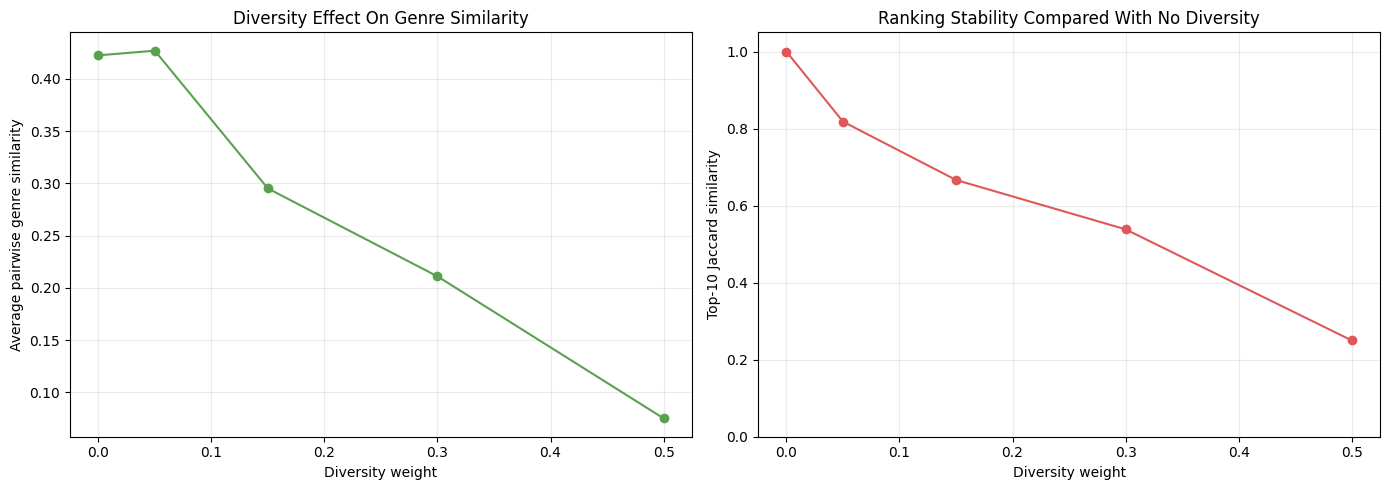

In [30]:
# Diversity counterfactual plots.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    diversity_df["diversity_weight"],
    diversity_df["avg_pairwise_genre_similarity"],
    marker="o",
    color="#59A14F",
)
axes[0].set_title("Diversity Effect On Genre Similarity")
axes[0].set_xlabel("Diversity weight")
axes[0].set_ylabel("Average pairwise genre similarity")
axes[0].grid(alpha=0.25)

axes[1].plot(
    diversity_df["diversity_weight"],
    diversity_df["top10_jaccard_with_no_diversity"],
    marker="o",
    color="#E15759",
)
axes[1].set_title("Ranking Stability Compared With No Diversity")
axes[1].set_xlabel("Diversity weight")
axes[1].set_ylabel("Top-10 Jaccard similarity")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.25)

plt.tight_layout()

### 11.1 Counterfactual Findings

These plots show how stable the recommendation list is when the model assumptions change. If the same movies remain highly ranked across scenarios, the recommendation is robust. If rankings change strongly, then the result depends heavily on the chosen balance between collaborative similarity, popularity, genre affinity, and diversity.

## 12. Optional Ranking NeuMF Sensitivity

The Ranking NeuMF model is harder to explain directly because it relies on latent user and movie embeddings. Instead of explaining embedding dimensions, we inspect genre occlusion sensitivity: how much the neural score changes when an active genre feature is removed.

This section is optional and will be skipped gracefully if PyTorch or the saved NeuMF artifacts are unavailable.

In [31]:
try:
    import torch
    from src.neural_cf import RankingNeuMF, safe_transform
    from src.explainability import rank_genre_occlusion_effects

    models_dir = PROJECT_ROOT / "models"
    with open(models_dir / "ranking_user_encoder.pkl", "rb") as f:
        user_encoder = pickle.load(f)
    with open(models_dir / "ranking_item_encoder.pkl", "rb") as f:
        item_encoder = pickle.load(f)
    with open(models_dir / "ranking_genre_cols.pkl", "rb") as f:
        ranking_genre_cols = pickle.load(f)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    neumf = RankingNeuMF(
        num_users=len(user_encoder.classes_),
        num_items=len(item_encoder.classes_),
        num_genres=len(ranking_genre_cols),
    ).to(device)
    try:
        state = torch.load(models_dir / "neumf_ranking_model.pth", map_location=device, weights_only=True)
    except TypeError:
        state = torch.load(models_dir / "neumf_ranking_model.pth", map_location=device)
    neumf.load_state_dict(state)

    target_movie_id = int(recommendations.iloc[0]["movieId"])
    movie_lookup = ranker.item_engine.df.drop_duplicates("movieId").set_index("movieId")

    if demo_user not in set(user_encoder.classes_) or target_movie_id not in set(item_encoder.classes_):
        print("Selected user/movie is not available in the Ranking NeuMF encoders; skipping neural sensitivity.")
    else:
        user_tensor = torch.tensor(safe_transform(user_encoder, [demo_user]), dtype=torch.long).to(device)
        item_tensor = torch.tensor(safe_transform(item_encoder, [target_movie_id]), dtype=torch.long).to(device)
        genre_tensor = torch.tensor(
            movie_lookup.loc[[target_movie_id], ranking_genre_cols].values,
            dtype=torch.float32,
        ).to(device)

        effects = rank_genre_occlusion_effects(
            neumf,
            user_tensor,
            item_tensor,
            genre_tensor,
            ranking_genre_cols,
            top_n=10,
        )
        effects_df = pd.DataFrame(effects)
        print(f"Ranking NeuMF genre sensitivity for: {recommendations.iloc[0]['title']}")
        display(effects_df)
except Exception as exc:
    print(f"Skipping Ranking NeuMF sensitivity analysis: {exc}")

Ranking NeuMF genre sensitivity for: Shopgirl (2005)


,genre,logit_drop_when_removed
0,Comedy,-0.017161
1,Romance,-0.057259
2,Drama,-0.060765


## 13. Interpretability Summary

The final model is interpretable at several levels:

- **Recommendation evidence:** similar movies from the user's history support recommendations.
- **Similar-liked-movies table:** collaborative evidence is expanded into exact supporting liked movies and similarity strengths.
- **Component decomposition:** each final score is split into item similarity, popularity, and genre affinity.
- **Feature-level drill-down:** item similarity is traced to exact liked movies, genre affinity to exact genres, and popularity to rating count versus global prior.
- **SHAP-style attribution:** structured hybrid features receive additive attributions.
- **User profile explanation:** genre profiles show what content preferences influence recommendations.
- **Exact genre contribution plots:** genre affinity is decomposed into the exact genres driving local and global recommendations.
- **Popularity breakdown:** Bayesian popularity is explained through movie rating count, movie mean rating, and global-prior influence.
- **Global analysis:** aggregated recommendations reveal which signals dominate overall.
- **Counterfactual analysis:** changing weights or diversity shows how stable the recommendations are.
- **Neural sensitivity:** Ranking NeuMF can be inspected through genre occlusion, while avoiding misleading explanations of latent embedding dimensions.

The main interpretability conclusion is that the Hybrid Ranker is the best final application model not only because it performs well, but because its decisions can be explained in a way that is faithful to the model and understandable for users.